# Spectral echelle resolution 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# For intrinsic broadening
# J0136 merged specs in 4826

wcal_red = fits.open('/home/benjamin/Documents/pypeit19b/redux_J0136/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')
wcal_blue = fits.open('/home/benjamin/Documents/pypeit19b/redux_J0136/blue/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')

In [3]:
# read the data
import pandas as pd
galname = 'J0136'
j0136 = pd.read_csv(galname + '.csv')

wave = j0136['wave'].to_numpy()
flux = j0136['flux'].to_numpy()
err = j0136['noise'].to_numpy()
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

In [4]:
wcal_red.info()

Filename: /home/benjamin/Documents/pypeit19b/redux_J0136/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  SPAT_IDS      1 ImageHDU        26   (8,)   int64   
  2  SPAT_ID-623_WAVEFIT    1 BinTableHDU     40   1R x 6C   [50D, 50D, 50J, 2048D, 2048D, 51D]   
  3  SPAT_ID-623_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [50D, 50D, 1K, 50D, 5D, 50K]   
  4  SPAT_ID-684_WAVEFIT    1 BinTableHDU     40   1R x 6C   [50D, 50D, 50J, 2048D, 2048D, 52D]   
  5  SPAT_ID-684_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [50D, 50D, 1K, 50D, 5D, 50K]   
  6  SPAT_ID-740_WAVEFIT    1 BinTableHDU     40   1R x 6C   [62D, 62D, 62J, 2048D, 2048D, 65D]   
  7  SPAT_ID-740_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [62D, 62D, 1K, 62D, 5D, 62K]   
  8  SPAT_ID-793_WAVEFIT    1 BinTableHDU     40   1R x 6C   [69D, 69D, 69J, 2048D, 2048D, 71D]   
  9  SPAT_ID-793_PYPEITFIT    1 B

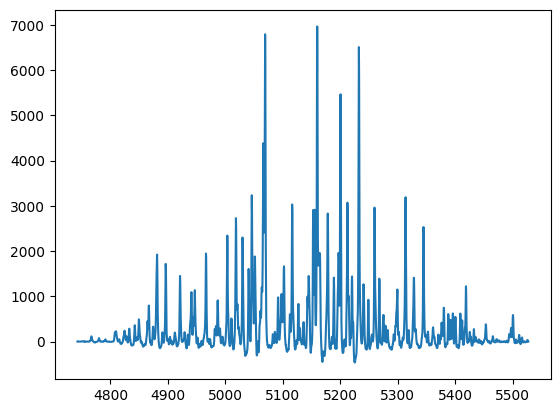

In [5]:
plt.plot(wcal_red[4].data['wave_soln'][0], wcal_red[4].data['spec'][0])

# Sky lines

In [6]:
J0136_fits = fits.open('/home/benjamin/Documents/pypeit19b/redux_J0136/red/magellan_mage_A/Science/spec1d_mage0073-J0136-0037_MagE_20190924T061419.000.fits')
J0136_fits.info()

Filename: /home/benjamin/Documents/pypeit19b/redux_J0136/red/magellan_mage_A/Science/spec1d_mage0073-J0136-0037_MagE_20190924T061419.000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      79   ()      
  1  OBJ0594-DET01-ORDER0013    1 BinTableHDU     72   2048R x 14C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1L, 1D, 1D, 1K]   
  2  OBJ0594-DET01-ORDER0012    1 BinTableHDU     72   2048R x 14C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1L, 1D, 1D, 1K]   
  3  OBJ0594-DET01-ORDER0011    1 BinTableHDU     72   2048R x 14C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1L, 1D, 1D, 1K]   
  4  OBJ0594-DET01-ORDER0010    1 BinTableHDU     72   2048R x 14C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1L, 1D, 1D, 1K]   
  5  OBJ0594-DET01-ORDER0009    1 BinTableHDU     72   2048R x 14C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1L, 1D, 1D, 1K]   
  6  OBJ0594-DET01-ORDER0008    1 BinTableHDU     72   2048R x 14C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D

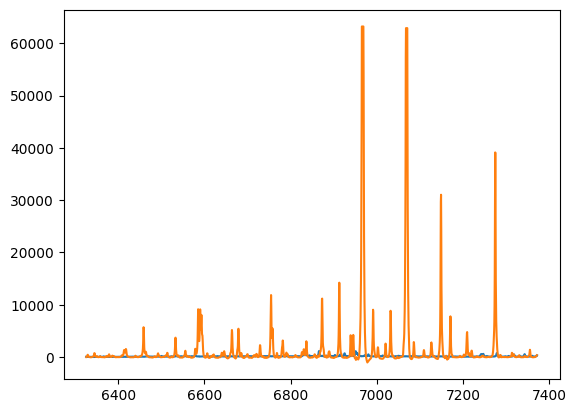

In [7]:
plt.plot(J0136_fits[5].data['BOX_WAVE'],
         J0136_fits[5].data['BOX_COUNTS_SKY'])
plt.plot(wcal_red[10].data['wave_soln'][0], wcal_red[10].data['spec'][0])
#plt.axvline(wave_cat['Ha']*(1 + z_BN[igal]), ls='--', color='gray')
#plt.axvline(wave_cat['[NII]6584']*(1 + z_BN[igal]), ls='--', color='gray')

#plt.axvline(wave_cat['[OII]7330']*(1 + z_BN[igal]), ls='--', color='gray')
#plt.axvline(wave_cat['HeI6678']*(1 + z_BN[igal]), ls='--', color='gray')
#plt.axvline(wave_cat['HeI7065']*(1 + z_BN[igal]), ls='--', color='gray')
#plt.axvline(wave_cat['[SII]6716']*(1 + z_BN[igal]), ls='--', color='gray')

# ARC -  Order 9 

## Part 1

In [8]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_arc9_1 = [6200*(1 + z_BN[igal]) - 20, 6200*(1 + z_BN[igal]) + 20]
mask_arc9_1 = (wcal_red[10].data['wave_soln'][0] >= wlims_arc9_1[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_arc9_1[1])

# Arc spectra around the fitted line
x_arc9_1 = wcal_red[10].data['wave_soln'][0][mask_arc9_1]
y_arc9_1 =  wcal_red[10].data['spec'][0][mask_arc9_1]

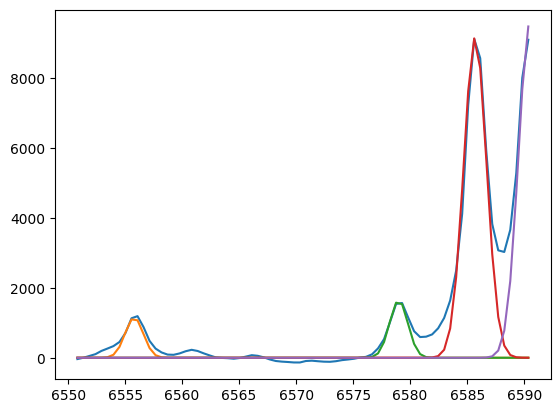

In [9]:
plt.plot(x_arc9_1, y_arc9_1)
plt.plot(x_arc9_1, gaussian(x_arc9_1, 2300, 6555.8, 0, 0.8))
plt.plot(x_arc9_1, gaussian(x_arc9_1, 3300, 6579, 0, 0.8))
plt.plot(x_arc9_1, gaussian(x_arc9_1, 23000, 6585.7, 0, 1.0))
plt.plot(x_arc9_1, gaussian(x_arc9_1, 24000, 6590.5, 0, 1.0))

100%|██████████████████████████████████████| 2500/2500 [00:24<00:00, 102.82it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 45.52395283 118.75338618  21.05694732  75.63208408 301.30428494
 275.22044844 175.14186283  92.39528867 191.39867864]


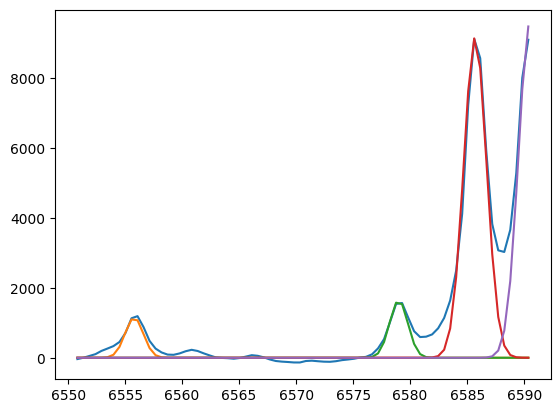

In [10]:
plt.plot(x_arc9_1, y_arc9_1)
plt.plot(x_arc9_1, gaussian(x_arc9_1,  2300,  6555.8, 0, 0.8))
plt.plot(x_arc9_1, gaussian(x_arc9_1,  3300,    6579, 0, 0.8))
plt.plot(x_arc9_1, gaussian(x_arc9_1, 23000,  6585.7, 0, 1.0))
plt.plot(x_arc9_1, gaussian(x_arc9_1, 24000,  6590.5, 0, 1.0))

params_arc9_1 = Parameters()
params_arc9_1.add('z', value=0.0, vary=False)
params_arc9_1.add('mu1', value=6555.8, vary=True)
params_arc9_1.add('mu2', value=  6579, vary=True)
params_arc9_1.add('mu3', value=6585.7, vary=True)
params_arc9_1.add('mu4', value=6590.5, vary=True)
params_arc9_1.add('arc1', value= 2300, min=0.)
params_arc9_1.add('arc2', value= 3300, min=0.)
params_arc9_1.add('arc3', value=23000, min=0.)
params_arc9_1.add('arc4', value=24000, min=0.)
params_arc9_1.add('sigma', value=0.9, min=0.)

def residual_arc9_1(params_arc9_1, x, data, uncertainty):
    
    z = params_arc9_1['z']
    mu1 = params_arc9_1['mu1']
    mu2 = params_arc9_1['mu2']
    mu3 = params_arc9_1['mu3']
    mu4 = params_arc9_1['mu4']
    flux1 = params_arc9_1['arc1']
    flux2 = params_arc9_1['arc2']
    flux3 = params_arc9_1['arc3']
    flux4 = params_arc9_1['arc4']
    sigma = params_arc9_1['sigma']
    
    x = x_arc9_1
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = model1 + model2 + model3 + model4
    return (model - y_arc9_1) / 10

np.random.seed(136)
out_arc9_1 = minimize(residual_arc9_1, params_arc9_1, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [11]:
out_arc9_1.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6555.85456,0.00758509,(0.00%),6555.8,-inf,inf,True
mu2,6579.28733,0.00595503,(0.00%),6579,-inf,inf,True
mu3,6585.79466,9.6262e-04,(0.00%),6585.7,-inf,inf,True
mu4,6590.43833,0.00266941,(0.00%),6590.5,-inf,inf,True
arc1,3172.07440,14.6476833,(0.46%),2300,0.00000000,inf,True
arc2,4381.49464,14.6689112,(0.33%),3300,0.00000000,inf,True
arc3,25105.9715,17.8558722,(0.07%),23000,0.00000000,inf,True
arc4,26340.6164,42.3121838,(0.16%),24000,0.00000000,inf,True
sigma,1.16192337,9.3632e-04,(0.08%),0.9,0.00000000,inf,True


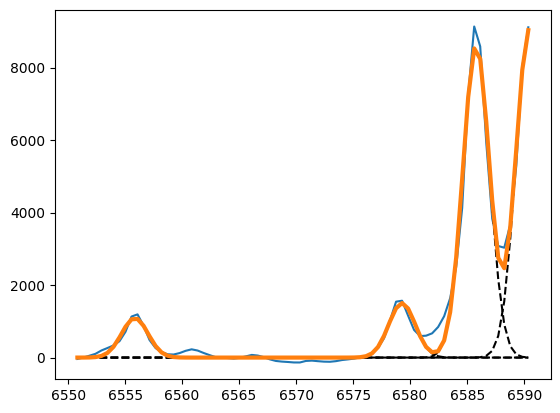

In [12]:
arc1_1 = out_arc9_1.flatchain.arc1.mean()
arc2_1 = out_arc9_1.flatchain.arc2.mean()
arc3_1 = out_arc9_1.flatchain.arc3.mean()
arc4_1 = out_arc9_1.flatchain.arc4.mean()

mu1_1 = out_arc9_1.flatchain.mu1.mean()
mu2_1 = out_arc9_1.flatchain.mu2.mean()
mu3_1 = out_arc9_1.flatchain.mu3.mean()
mu4_1 = out_arc9_1.flatchain.mu4.mean()

sigma_arc9_1 = out_arc9_1.flatchain.sigma.mean()

plt.plot(x_arc9_1, y_arc9_1)
plt.plot(x_arc9_1, gaussian(x_arc9_1, arc1_1, mu1_1, 0, sigma_arc9_1), color='black', ls='--')
plt.plot(x_arc9_1, gaussian(x_arc9_1, arc2_1, mu2_1, 0, sigma_arc9_1), color='black', ls='--')
plt.plot(x_arc9_1, gaussian(x_arc9_1, arc3_1, mu3_1, 0, sigma_arc9_1), color='black', ls='--')
plt.plot(x_arc9_1, gaussian(x_arc9_1, arc4_1, mu4_1, 0, sigma_arc9_1), color='black', ls='--')

plt.plot(x_arc9_1, gaussian(x_arc9_1, arc1_1, mu1_1, 0, sigma_arc9_1) \
                 + gaussian(x_arc9_1, arc2_1, mu2_1, 0, sigma_arc9_1) \
                 + gaussian(x_arc9_1, arc3_1, mu3_1, 0, sigma_arc9_1) \
                 + gaussian(x_arc9_1, arc4_1, mu4_1, 0, sigma_arc9_1), lw=3
)

## Part 2

In [13]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_arc9_2 = [6511*(1 + z_BN[igal]) - 20, 6511*(1 + z_BN[igal]) + 20]
mask_arc9_2 = (wcal_red[10].data['wave_soln'][0] >= wlims_arc9_2[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_arc9_2[1])

# Arc spectra around the fitted line
x_arc9_2 = wcal_red[10].data['wave_soln'][0][mask_arc9_2]
y_arc9_2 =  wcal_red[10].data['spec'][0][mask_arc9_2]

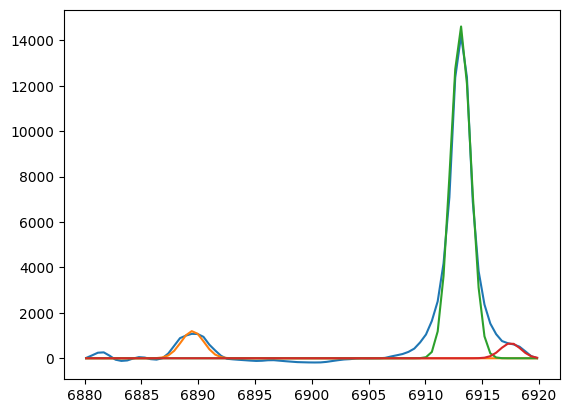

In [14]:
plt.plot(x_arc9_2, y_arc9_2)
plt.plot(x_arc9_2, gaussian(x_arc9_2, 3000, 6889.5, 0, 1.0))
plt.plot(x_arc9_2, gaussian(x_arc9_2, 33000, 6913.1, 0, 0.9))
plt.plot(x_arc9_2, gaussian(x_arc9_2, 1500, 6917.5, 0, 0.9))

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 115.69it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 44.54108121  59.97529125  23.31188173 157.9036396  127.27396289
 233.74456048 162.99803265]


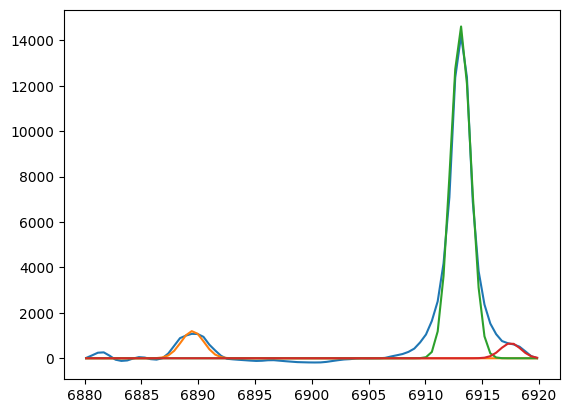

In [15]:
plt.plot(x_arc9_2, y_arc9_2)
plt.plot(x_arc9_2, gaussian(x_arc9_2,  3000, 6889.5, 0, 1.0))
plt.plot(x_arc9_2, gaussian(x_arc9_2, 33000, 6913.1, 0, 0.9))
plt.plot(x_arc9_2, gaussian(x_arc9_2,  1500, 6917.5, 0, 0.9))

params_arc9_2 = Parameters()
params_arc9_2.add('z', value=0.0, vary=False)
params_arc9_2.add('mu1', value=6889.5, vary=True)
params_arc9_2.add('mu2', value=6913.1, vary=True)
params_arc9_2.add('mu3', value=6917.5, vary=True)
params_arc9_2.add('arc1', value= 3000, min=0.)
params_arc9_2.add('arc2', value=33000, min=0.)
params_arc9_2.add('arc3', value= 1500, min=0.)
params_arc9_2.add('sigma', value=0.9, min=0.)

def residual_arc9_2(params_arc9_2, x, data, uncertainty):
    
    z = params_arc9_2['z']
    mu1 = params_arc9_2['mu1']
    mu2 = params_arc9_2['mu2']
    mu3 = params_arc9_2['mu3']
    flux1 = params_arc9_2['arc1']
    flux2 = params_arc9_2['arc2']
    flux3 = params_arc9_2['arc3']
    sigma = params_arc9_2['sigma']
    
    x = x_arc9_2
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = model1 + model2 + model3
    return (model - y_arc9_2) / 10

np.random.seed(136)
out_arc9_2 = minimize(residual_arc9_2, params_arc9_2, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [16]:
out_arc9_2.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6889.51841,0.00694314,(0.00%),6889.5,-inf,inf,True
mu2,6913.10863,5.9232e-04,(0.00%),6913.1,-inf,inf,True
mu3,6916.26037,0.00948635,(0.00%),6917.5,-inf,inf,True
arc1,3131.69028,13.3498879,(0.43%),3000,0.00000000,inf,True
arc2,33657.7869,19.9032180,(0.06%),33000,0.00000000,inf,True
arc3,2768.59430,14.1327135,(0.51%),1500,0.00000000,inf,True
sigma,0.96877099,7.1674e-04,(0.07%),0.9,0.00000000,inf,True


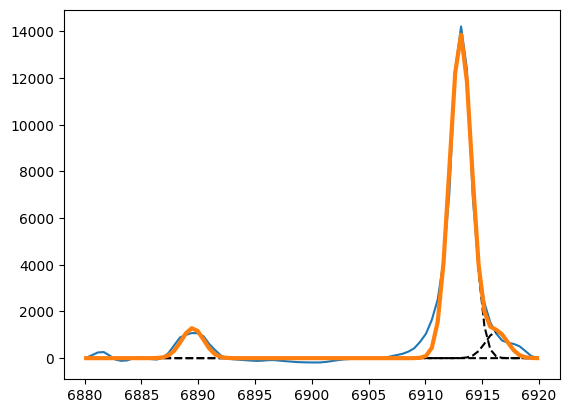

In [17]:
arc1_2 = out_arc9_2.flatchain.arc1.mean()
arc2_2 = out_arc9_2.flatchain.arc2.mean()
arc3_2 = out_arc9_2.flatchain.arc3.mean()

mu1_2 = out_arc9_2.flatchain.mu1.mean()
mu2_2 = out_arc9_2.flatchain.mu2.mean()
mu3_2 = out_arc9_2.flatchain.mu3.mean()

sigma_arc9_2 = out_arc9_2.flatchain.sigma.mean()

plt.plot(x_arc9_2, y_arc9_2)
plt.plot(x_arc9_2, gaussian(x_arc9_2, arc1_2, mu1_2, 0, sigma_arc9_2), color='black', ls='--')
plt.plot(x_arc9_2, gaussian(x_arc9_2, arc2_2, mu2_2, 0, sigma_arc9_2), color='black', ls='--')
plt.plot(x_arc9_2, gaussian(x_arc9_2, arc3_2, mu3_2, 0, sigma_arc9_2), color='black', ls='--')

plt.plot(x_arc9_2, gaussian(x_arc9_2, arc1_2, mu1_2, 0, sigma_arc9_2) \
                 + gaussian(x_arc9_2, arc2_2, mu2_2, 0, sigma_arc9_2) \
                 + gaussian(x_arc9_2, arc3_2, mu3_2, 0, sigma_arc9_2), lw=3
)

## Part 3

In [18]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_arc9_3 = [6888*(1 + z_BN[igal]) - 15, 6888*(1 + z_BN[igal]) + 20]
mask_arc9_3 = (wcal_red[10].data['wave_soln'][0] >= wlims_arc9_3[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_arc9_3[1])

# Arc spectra around the fitted line
x_arc9_3 = wcal_red[10].data['wave_soln'][0][mask_arc9_3]
y_arc9_3 =  wcal_red[10].data['spec'][0][mask_arc9_3]

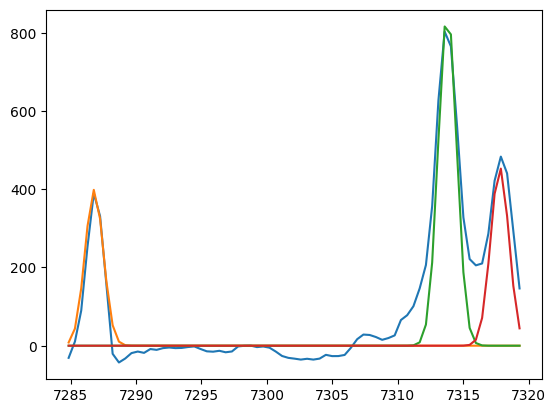

In [19]:
plt.plot(x_arc9_3, y_arc9_3)
plt.plot(x_arc9_3, gaussian(x_arc9_3, 700, 7286.8, 0, 0.7))
plt.plot(x_arc9_3, gaussian(x_arc9_3, 1500, 7313.8, 0, 0.7))
plt.plot(x_arc9_3, gaussian(x_arc9_3, 800, 7317.8, 0, 0.7))

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 116.06it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 43.57402956  32.17485137  45.6780525  105.16074649 177.5310095
 185.95513261 153.56232969]


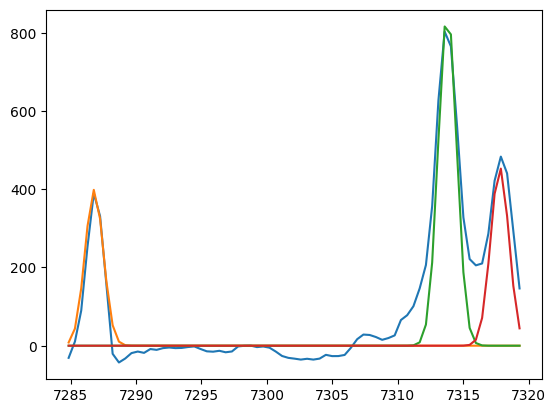

In [20]:
plt.plot(x_arc9_3, y_arc9_3)
plt.plot(x_arc9_3, gaussian(x_arc9_3,  700, 7286.8, 0, 0.7))
plt.plot(x_arc9_3, gaussian(x_arc9_3, 1500, 7313.8, 0, 0.7))
plt.plot(x_arc9_3, gaussian(x_arc9_3,  800, 7317.8, 0, 0.7))

params_arc9_3 = Parameters()
params_arc9_3.add('z', value=0.0, vary=False)
params_arc9_3.add('mu1', value=7286.8, vary=True)
params_arc9_3.add('mu2', value=7313.8, vary=True)
params_arc9_3.add('mu3', value=7317.8, vary=True)
params_arc9_3.add('arc1', value= 700, min=0.)
params_arc9_3.add('arc2', value=1500, min=0.)
params_arc9_3.add('arc3', value= 800, min=0.)
params_arc9_3.add('sigma', value=0.7, min=0.)

def residual_arc9_3(params_arc9_3, x, data, uncertainty):
    
    z = params_arc9_3['z']
    mu1 = params_arc9_3['mu1']
    mu2 = params_arc9_3['mu2']
    mu3 = params_arc9_3['mu3']
    flux1 = params_arc9_3['arc1']
    flux2 = params_arc9_3['arc2']
    flux3 = params_arc9_3['arc3']
    sigma = params_arc9_3['sigma']
    
    x = x_arc9_3
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = model1 + model2 + model3
    return (model - y_arc9_3) / 10

np.random.seed(136)
out_arc9_3 = minimize(residual_arc9_3, params_arc9_3, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [21]:
out_arc9_3.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7286.83010,0.01917728,(0.00%),7286.8,-inf,inf,True
mu2,7313.76876,0.00924277,(0.00%),7313.8,-inf,inf,True
mu3,7317.83688,0.01588193,(0.00%),7317.8,-inf,inf,True
arc1,706.665935,12.9312631,(1.83%),700,0.00000000,inf,True
arc2,1916.34772,15.0074724,(0.78%),1500,0.00000000,inf,True
arc3,1171.30837,13.3865938,(1.14%),800,0.00000000,inf,True
sigma,0.95332207,0.00722421,(0.76%),0.7,0.00000000,inf,True


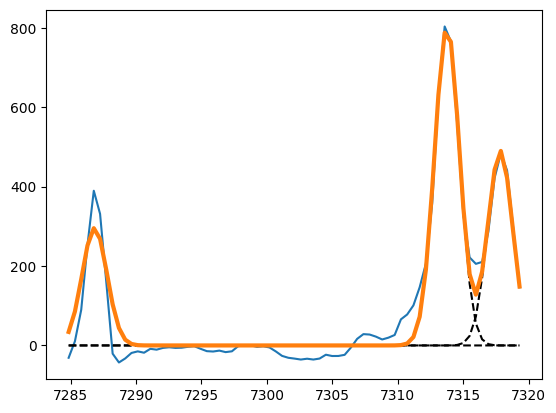

In [22]:
arc1_3 = out_arc9_3.flatchain.arc1.mean()
arc2_3 = out_arc9_3.flatchain.arc2.mean()
arc3_3 = out_arc9_3.flatchain.arc3.mean()

mu1_3 = out_arc9_3.flatchain.mu1.mean()
mu2_3 = out_arc9_3.flatchain.mu2.mean()
mu3_3 = out_arc9_3.flatchain.mu3.mean()

sigma_arc9_3 = out_arc9_3.flatchain.sigma.mean()

plt.plot(x_arc9_3, y_arc9_3)
plt.plot(x_arc9_3, gaussian(x_arc9_3, arc1_3, mu1_3, 0, sigma_arc9_3), color='black', ls='--')
plt.plot(x_arc9_3, gaussian(x_arc9_3, arc2_3, mu2_3, 0, sigma_arc9_3), color='black', ls='--')
plt.plot(x_arc9_3, gaussian(x_arc9_3, arc3_3, mu3_3, 0, sigma_arc9_3), color='black', ls='--')

plt.plot(x_arc9_3, gaussian(x_arc9_3, arc1_3, mu1_3, 0, sigma_arc9_3) \
                 + gaussian(x_arc9_3, arc2_3, mu2_3, 0, sigma_arc9_3) \
                 + gaussian(x_arc9_3, arc3_3, mu3_3, 0, sigma_arc9_3), lw=3
)

# SKY -  Order 9 

## Part 1

In [23]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_sky9_1 = [6200*(1 + z_BN[igal]) - 20, 6200*(1 + z_BN[igal]) + 20]
mask_sky9_1 = (J0136_fits[5].data['BOX_WAVE'] >= wlims_sky9_1[0]) & (J0136_fits[5].data['BOX_WAVE'] < wlims_sky9_1[1])

# Arc spectra around the fitted line
x_sky9_1 = J0136_fits[5].data['BOX_WAVE'][mask_sky9_1]
y_sky9_1 = J0136_fits[5].data['BOX_COUNTS_SKY'][mask_sky9_1]

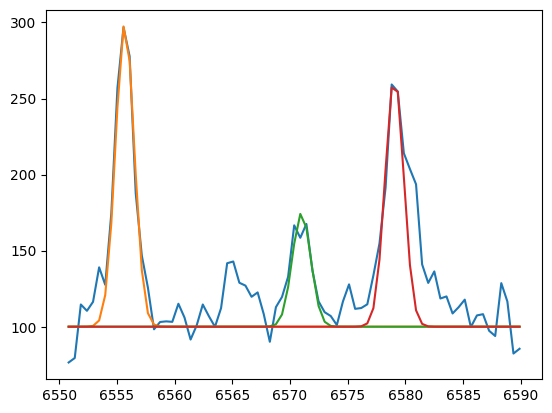

In [24]:
plt.plot(x_sky9_1, y_sky9_1)
plt.plot(x_sky9_1, 100 + gaussian(x_sky9_1, 400, 6555.7, 0, 0.8))
plt.plot(x_sky9_1, 100 + gaussian(x_sky9_1, 150, 6571, 0, 0.8))
plt.plot(x_sky9_1, 100 + gaussian(x_sky9_1, 330, 6579.05, 0, 0.8))

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 115.13it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 55.17228177  62.94438027  59.94193751  73.67037597  67.87787854
  86.96628613  95.34835269 102.22790628]


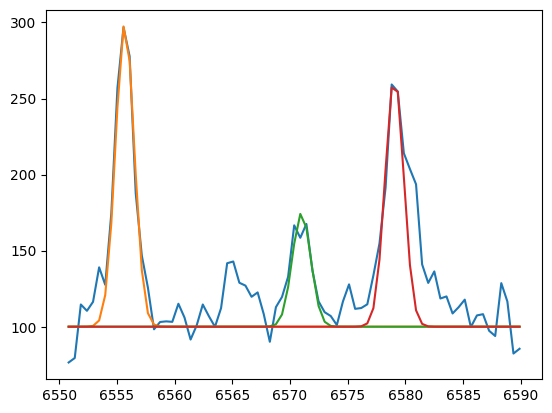

In [25]:
plt.plot(x_sky9_1, y_sky9_1)
plt.plot(x_sky9_1, 100 + gaussian(x_sky9_1, 400,  6555.7, 0, 0.8))
plt.plot(x_sky9_1, 100 + gaussian(x_sky9_1, 150,    6571, 0, 0.8))
plt.plot(x_sky9_1, 100 + gaussian(x_sky9_1, 330, 6579.05, 0, 0.8))

params_sky9_1 = Parameters()
params_sky9_1.add('z', value=0.0, vary=False)
params_sky9_1.add('mu1', value= 6555.7, vary=True)
params_sky9_1.add('mu2', value=   6571, vary=True)
params_sky9_1.add('mu3', value=6579.05, vary=True)
params_sky9_1.add('arc1', value=400, min=0.)
params_sky9_1.add('arc2', value=150, min=0.)
params_sky9_1.add('arc3', value=330, min=0.)
params_sky9_1.add('sigma', value=0.8, min=0.)
params_sky9_1.add('bkg', value=100, vary=True)

def residual_sky9_1(params_sky9_1, x, data, uncertainty):
    
    z = params_sky9_1['z']
    mu1 = params_sky9_1['mu1']
    mu2 = params_sky9_1['mu2']
    mu3 = params_sky9_1['mu3']
    flux1 = params_sky9_1['arc1']
    flux2 = params_sky9_1['arc2']
    flux3 = params_sky9_1['arc3']
    sigma = params_sky9_1['sigma']
    bkg = params_sky9_1['bkg']
    
    x = x_sky9_1
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_sky9_1) / 10

np.random.seed(136)
out_sky9_1 = minimize(residual_sky9_1, params_sky9_1, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [26]:
out_sky9_1.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6555.64780,0.04015332,(0.00%),6555.7,-inf,inf,True
mu2,6570.90706,0.12521773,(0.00%),6571,-inf,inf,True
mu3,6579.35632,0.05795012,(0.00%),6579.05,-inf,inf,True
arc1,411.689236,16.9295389,(4.11%),400,0.00000000,inf,True
arc2,130.564597,14.9106565,(11.42%),150,0.00000000,inf,True
arc3,368.213173,17.8260144,(4.84%),330,0.00000000,inf,True
sigma,0.95291604,0.03809246,(4.00%),0.8,0.00000000,inf,True
bkg,110.074112,1.48330279,(1.35%),100,-inf,inf,True


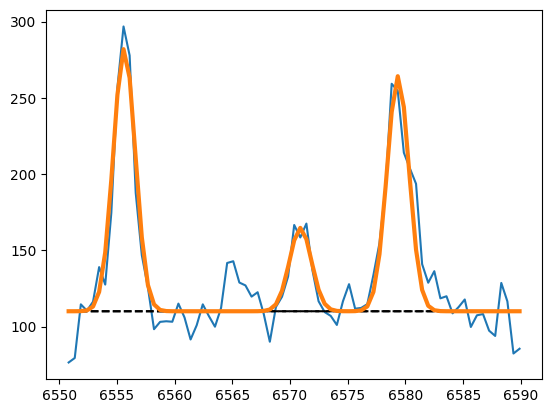

In [27]:
arc1_sky9_1 = out_sky9_1.flatchain.arc1.mean()
arc2_sky9_1 = out_sky9_1.flatchain.arc2.mean()
arc3_sky9_1 = out_sky9_1.flatchain.arc3.mean()

mu1_sky9_1 = out_sky9_1.flatchain.mu1.mean()
mu2_sky9_1 = out_sky9_1.flatchain.mu2.mean()
mu3_sky9_1 = out_sky9_1.flatchain.mu3.mean()

sigma_sky9_1 = out_sky9_1.flatchain.sigma.mean()
bkg_sky9_1 = out_sky9_1.flatchain.bkg.mean()

plt.plot(x_sky9_1, y_sky9_1)
plt.plot(x_sky9_1, bkg_sky9_1 + gaussian(x_sky9_1, arc1_sky9_1, mu1_sky9_1, 0, sigma_sky9_1), color='black', ls='--')
plt.plot(x_sky9_1, bkg_sky9_1 + gaussian(x_sky9_1, arc2_sky9_1, mu2_sky9_1, 0, sigma_sky9_1), color='black', ls='--')
plt.plot(x_sky9_1, bkg_sky9_1 + gaussian(x_sky9_1, arc3_sky9_1, mu3_sky9_1, 0, sigma_sky9_1), color='black', ls='--')

plt.plot(x_sky9_1, bkg_sky9_1 + gaussian(x_sky9_1, arc1_sky9_1, mu1_sky9_1, 0, sigma_sky9_1) \
                              + gaussian(x_sky9_1, arc2_sky9_1, mu2_sky9_1, 0, sigma_sky9_1) \
                              + gaussian(x_sky9_1, arc3_sky9_1, mu3_sky9_1, 0, sigma_sky9_1), lw=3
)

## Part 2

In [28]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_sky9_2 = [6511*(1 + z_BN[igal]) - 20, 6511*(1 + z_BN[igal]) + 20]
mask_sky9_2 = (J0136_fits[5].data['BOX_WAVE'] >= wlims_sky9_2[0]) & (J0136_fits[5].data['BOX_WAVE'] < wlims_sky9_2[1])

# Arc spectra around the fitted line
x_sky9_2 = J0136_fits[5].data['BOX_WAVE'][mask_sky9_2]
y_sky9_2 = J0136_fits[5].data['BOX_COUNTS_SKY'][mask_sky9_2]

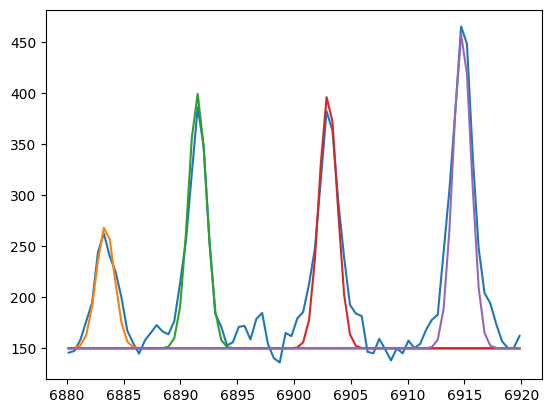

In [29]:
plt.plot(x_sky9_2, y_sky9_2)
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 240, 6883.4, 0, 0.8))
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 500, 6891.5, 0, 0.8))
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 500, 6903, 0, 0.8))
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 620, 6914.8, 0, 0.8))

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 97.01it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 10 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 71.07013336  64.57781823  71.8599206   53.88679148  77.37783908
 127.94312408  74.09991255 169.28166725 179.88703042 115.35915917]


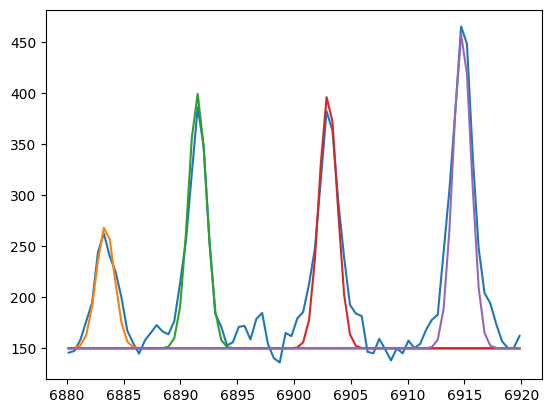

In [30]:
plt.plot(x_sky9_2, y_sky9_2)
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 240, 6883.4, 0, 0.8))
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 500, 6891.5, 0, 0.8))
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 500,   6903, 0, 0.8))
plt.plot(x_sky9_2, 150 + gaussian(x_sky9_2, 620, 6914.8, 0, 0.8))

params_sky9_2 = Parameters()
params_sky9_2.add('z', value=0.0, vary=False)
params_sky9_2.add('mu1', value=6883.4, vary=True)
params_sky9_2.add('mu2', value=6891.5, vary=True)
params_sky9_2.add('mu3', value=  6903, vary=True)
params_sky9_2.add('mu4', value=6914.8, vary=True)
params_sky9_2.add('arc1', value=240, min=0.)
params_sky9_2.add('arc2', value=500, min=0.)
params_sky9_2.add('arc3', value=500, min=0.)
params_sky9_2.add('arc4', value=620, min=0.)
params_sky9_2.add('sigma', value=0.8, min=0.)
params_sky9_2.add('bkg', value=150, vary=True)

def residual_sky9_2(params_sky9_2, x, data, uncertainty):
    
    z = params_sky9_2['z']
    mu1 = params_sky9_2['mu1']
    mu2 = params_sky9_2['mu2']
    mu3 = params_sky9_2['mu3']
    mu4 = params_sky9_2['mu4']
    flux1 = params_sky9_2['arc1']
    flux2 = params_sky9_2['arc2']
    flux3 = params_sky9_2['arc3']
    flux4 = params_sky9_2['arc4']
    sigma = params_sky9_2['sigma']
    bkg = params_sky9_2['bkg']
    
    x = x_sky9_2
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_sky9_2) / 10

np.random.seed(136)
out_sky9_2 = minimize(residual_sky9_2, params_sky9_2, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [31]:
out_sky9_2.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6883.42177,0.07342724,(0.00%),6883.4,-inf,inf,True
mu2,6891.52028,0.03417333,(0.00%),6891.5,-inf,inf,True
mu3,6903.04798,0.03591659,(0.00%),6903,-inf,inf,True
mu4,6914.82301,0.02412925,(0.00%),6914.8,-inf,inf,True
arc1,232.779744,15.2203742,(6.54%),240,0.00000000,inf,True
arc2,477.713646,15.6488518,(3.28%),500,0.00000000,inf,True
arc3,510.060143,16.5364423,(3.24%),500,0.00000000,inf,True
arc4,709.820259,17.6182627,(2.48%),620,0.00000000,inf,True
sigma,0.93333545,0.02092266,(2.24%),0.8,0.00000000,inf,True


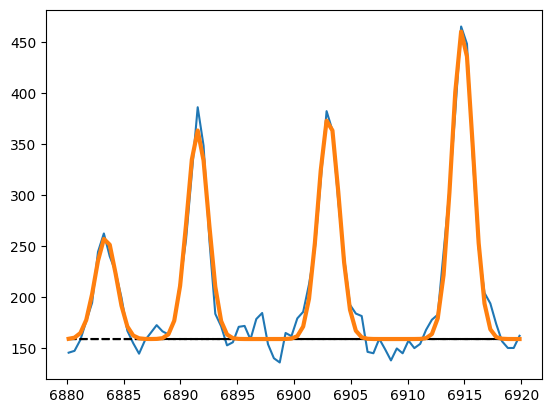

In [32]:
arc1_sky9_2 = out_sky9_2.flatchain.arc1.mean()
arc2_sky9_2 = out_sky9_2.flatchain.arc2.mean()
arc3_sky9_2 = out_sky9_2.flatchain.arc3.mean()
arc4_sky9_2 = out_sky9_2.flatchain.arc4.mean()

mu1_sky9_2 = out_sky9_2.flatchain.mu1.mean()
mu2_sky9_2 = out_sky9_2.flatchain.mu2.mean()
mu3_sky9_2 = out_sky9_2.flatchain.mu3.mean()
mu4_sky9_2 = out_sky9_2.flatchain.mu4.mean()

sigma_sky9_2 = out_sky9_2.flatchain.sigma.mean()
bkg_sky9_2 = out_sky9_2.flatchain.bkg.mean()

plt.plot(x_sky9_2, y_sky9_2)
plt.plot(x_sky9_2, bkg_sky9_2 + gaussian(x_sky9_2, arc1_sky9_2, mu1_sky9_2, 0, sigma_sky9_2), color='black', ls='--')
plt.plot(x_sky9_2, bkg_sky9_2 + gaussian(x_sky9_2, arc2_sky9_2, mu2_sky9_2, 0, sigma_sky9_2), color='black', ls='--')
plt.plot(x_sky9_2, bkg_sky9_2 + gaussian(x_sky9_2, arc3_sky9_2, mu3_sky9_2, 0, sigma_sky9_2), color='black', ls='--')
plt.plot(x_sky9_2, bkg_sky9_2 + gaussian(x_sky9_2, arc4_sky9_2, mu4_sky9_2, 0, sigma_sky9_2), color='black', ls='--')

plt.plot(x_sky9_2, bkg_sky9_2 + gaussian(x_sky9_2, arc1_sky9_2, mu1_sky9_2, 0, sigma_sky9_2) \
                              + gaussian(x_sky9_2, arc2_sky9_2, mu2_sky9_2, 0, sigma_sky9_2) \
                              + gaussian(x_sky9_2, arc3_sky9_2, mu3_sky9_2, 0, sigma_sky9_2) \
                              + gaussian(x_sky9_2, arc4_sky9_2, mu4_sky9_2, 0, sigma_sky9_2), lw=3
)

## Part 3

In [33]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_sky9_3 = [6888*(1 + z_BN[igal]) - 16, 6888*(1 + z_BN[igal]) + 20]
mask_sky9_3 = (J0136_fits[5].data['BOX_WAVE'] >= wlims_sky9_3[0]) & (J0136_fits[5].data['BOX_WAVE'] < wlims_sky9_3[1])

# Arc spectra around the fitted line
x_sky9_3 = J0136_fits[5].data['BOX_WAVE'][mask_sky9_3]
y_sky9_3 = J0136_fits[5].data['BOX_COUNTS_SKY'][mask_sky9_3]

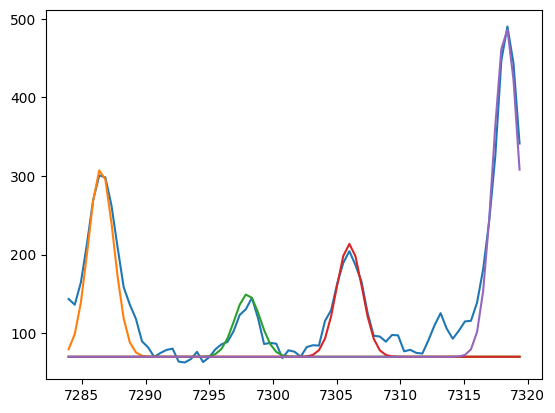

In [34]:
plt.plot(x_sky9_3, y_sky9_3)
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3,  600, 7286.5, 0, 1.0))
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3,  200,   7298, 0, 1.0))
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3,  360,   7306, 0, 1.0))
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3, 1050, 7318.3, 0, 1.0))

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 99.58it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 10 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 66.55595999  75.53600481  66.23517986  79.11624305  83.10321572
 239.24964658 176.99589187  82.62266333 125.29626619 223.3478892 ]


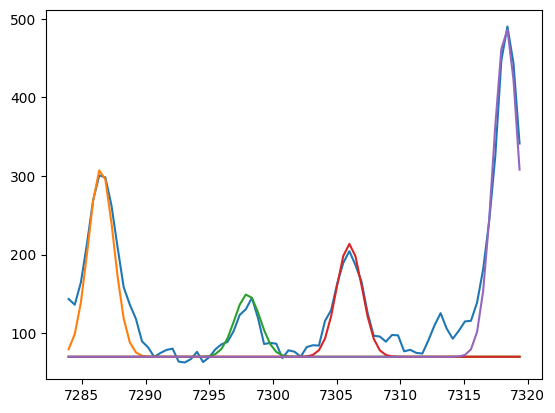

In [35]:
plt.plot(x_sky9_3, y_sky9_3)
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3,  600, 7286.5, 0, 1.0))
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3,  200,   7298, 0, 1.0))
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3,  360,   7306, 0, 1.0))
plt.plot(x_sky9_3, 70 + gaussian(x_sky9_3, 1050, 7318.3, 0, 1.0))

params_sky9_3 = Parameters()
params_sky9_3.add('z', value=0.0, vary=False)
params_sky9_3.add('mu1', value=7286.5, vary=True)
params_sky9_3.add('mu2', value=  7298, vary=True)
params_sky9_3.add('mu3', value=  7306, vary=True)
params_sky9_3.add('mu4', value=7318.3, vary=True)
params_sky9_3.add('arc1', value= 600, min=0.)
params_sky9_3.add('arc2', value= 200, min=0.)
params_sky9_3.add('arc3', value= 360, min=0.)
params_sky9_3.add('arc4', value=1050, min=0.)
params_sky9_3.add('sigma', value=1.0, min=0.)
params_sky9_3.add('bkg', value=70, vary=True)

def residual_sky9_3(params_sky9_3, x, data, uncertainty):
    
    z = params_sky9_3['z']
    mu1 = params_sky9_3['mu1']
    mu2 = params_sky9_3['mu2']
    mu3 = params_sky9_3['mu3']
    mu4 = params_sky9_3['mu4']
    flux1 = params_sky9_3['arc1']
    flux2 = params_sky9_3['arc2']
    flux3 = params_sky9_3['arc3']
    flux4 = params_sky9_3['arc4']
    sigma = params_sky9_3['sigma']
    bkg = params_sky9_3['bkg']
    
    x = x_sky9_3
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_sky9_3) / 10

np.random.seed(136)
out_sky9_3 = minimize(residual_sky9_3, params_sky9_3, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [36]:
out_sky9_3.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7286.56684,0.03749270,(0.00%),7286.5,-inf,inf,True
mu2,7298.03769,0.14431001,(0.00%),7298,-inf,inf,True
mu3,7305.97717,0.06850869,(0.00%),7306,-inf,inf,True
mu4,7318.43311,0.02708422,(0.00%),7318.3,-inf,inf,True
arc1,644.855608,19.6168374,(3.04%),600,0.00000000,inf,True
arc2,123.740241,15.3444330,(12.40%),200,0.00000000,inf,True
arc3,324.980916,16.8693067,(5.19%),360,0.00000000,inf,True
arc4,1108.75699,25.9708237,(2.34%),1050,0.00000000,inf,True
sigma,1.14680160,0.02841522,(2.48%),1.0,0.00000000,inf,True


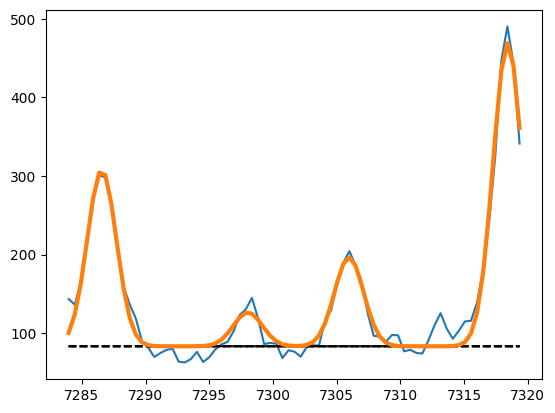

In [37]:
arc1_sky9_3 = out_sky9_3.flatchain.arc1.mean()
arc2_sky9_3 = out_sky9_3.flatchain.arc2.mean()
arc3_sky9_3 = out_sky9_3.flatchain.arc3.mean()
arc4_sky9_3 = out_sky9_3.flatchain.arc4.mean()

mu1_sky9_3 = out_sky9_3.flatchain.mu1.mean()
mu2_sky9_3 = out_sky9_3.flatchain.mu2.mean()
mu3_sky9_3 = out_sky9_3.flatchain.mu3.mean()
mu4_sky9_3 = out_sky9_3.flatchain.mu4.mean()

sigma_sky9_3 = out_sky9_3.flatchain.sigma.mean()
bkg_sky9_3 = out_sky9_3.flatchain.bkg.mean()

plt.plot(x_sky9_3, y_sky9_3)
plt.plot(x_sky9_3, bkg_sky9_3 + gaussian(x_sky9_3, arc1_sky9_3, mu1_sky9_3, 0, sigma_sky9_3), color='black', ls='--')
plt.plot(x_sky9_3, bkg_sky9_3 + gaussian(x_sky9_3, arc2_sky9_3, mu2_sky9_3, 0, sigma_sky9_3), color='black', ls='--')
plt.plot(x_sky9_3, bkg_sky9_3 + gaussian(x_sky9_3, arc3_sky9_3, mu3_sky9_3, 0, sigma_sky9_3), color='black', ls='--')
plt.plot(x_sky9_3, bkg_sky9_3 + gaussian(x_sky9_3, arc4_sky9_3, mu4_sky9_3, 0, sigma_sky9_3), color='black', ls='--')

plt.plot(x_sky9_3, bkg_sky9_3 + gaussian(x_sky9_3, arc1_sky9_3, mu1_sky9_3, 0, sigma_sky9_3) \
                              + gaussian(x_sky9_3, arc2_sky9_3, mu2_sky9_3, 0, sigma_sky9_3) \
                              + gaussian(x_sky9_3, arc3_sky9_3, mu3_sky9_3, 0, sigma_sky9_3) \
                              + gaussian(x_sky9_3, arc4_sky9_3, mu4_sky9_3, 0, sigma_sky9_3), lw=3
)

# Growth

In [38]:
wave_sky9 = np.array([6200, 6511, 6888]) * (1 + z_BN[igal])
sigma_sky9 = np.array([sigma_sky9_1, sigma_sky9_2, sigma_sky9_3])

wave_arc9 = np.array([6200, 6511, 6888]) * (1 + z_BN[igal])
sigma_arc9 = np.array([sigma_arc9_1, sigma_arc9_2, sigma_arc9_3])

In [39]:
wave_sky9

array([6570.388  , 6899.96714, 7299.48912])

In [40]:
sigma_sky9

array([0.95383926, 0.93387183, 1.14680285])

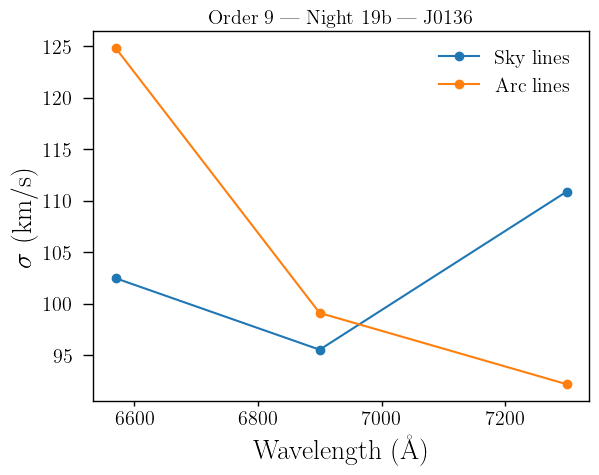

In [41]:
texPlot('on')

plt.plot(wave_sky9, FWHM(sigma_sky9, wave_sky9), marker='o', label='Sky lines')
plt.plot(wave_arc9, FWHM(sigma_arc9, wave_arc9), marker='o', label='Arc lines')
plt.title('Order 9 | Night 19b | J0136')
plt.xlabel('Wavelength (\AA)')
plt.ylabel('$\sigma$ (km/s)')
plt.legend()